In [2]:
# ── Cell 1 · Config & Environment Setup · V2 ─────────────────────────────────

import os, random, warnings
import numpy as np
import torch
import torchvision.transforms as T
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"]       = str(seed)

seed_everything(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR  = Path("/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")
CKPT_DIR  = Path("/kaggle/working/checkpoints")
LOG_DIR   = Path("/kaggle/working/logs")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────────
NUM_CLASSES   = 5
CLASS_NAMES   = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
IMG_SIZE      = 224

# ── Training · V2 changes ─────────────────────────────────────────────────────
BATCH_SIZE    = 32
NUM_EPOCHS    = 25         # ↑ was 20
NUM_WORKERS   = 2
PIN_MEMORY    = True

# ── Optimiser ─────────────────────────────────────────────────────────────────
LR_HEAD       = 1e-3
LR_BACKBONE   = 5e-5       # ↓ was 1e-4 — gentler on unfrozen blocks
WEIGHT_DECAY  = 1e-2
WARMUP_EPOCHS = 2

# ── Regularisation ────────────────────────────────────────────────────────────
DROPOUT       = 0.3
LABEL_SMOOTH  = 0.1

# ── Focal loss params · V2 new ────────────────────────────────────────────────
FOCAL_GAMMA   = 2.0        # focuses on hard examples (Mild, Moderate)
FOCAL_ALPHA   = None       # we use weighted sampler so no need for alpha here

# ── Unfreeze · V2 changes ─────────────────────────────────────────────────────
UNFREEZE_EPOCH  = 3        # same epoch
UNFREEZE_BLOCKS = 5        # ↑ was 3

# ── Early stopping · V2 changes ───────────────────────────────────────────────
PATIENCE      = 7          # ↑ was 5
MONITOR       = "val_qwk"

# ── Mixed precision ───────────────────────────────────────────────────────────
USE_AMP       = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity check ──────────────────────────────────────────────────────────────
print("=" * 50)
print(f"  Version     : V2")
print(f"  Device      : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Data dir    : {DATA_DIR}")
print(f"  Batch size  : {BATCH_SIZE}  |  Image size : {IMG_SIZE}")
print(f"  Epochs      : {NUM_EPOCHS}  |  Patience   : {PATIENCE}")
print(f"  LR head     : {LR_HEAD}  |  LR backbone : {LR_BACKBONE}")
print(f"  Unfreeze    : epoch {UNFREEZE_EPOCH}, {UNFREEZE_BLOCKS} blocks")
print(f"  Loss        : Focal (gamma={FOCAL_GAMMA})")
print(f"  AMP         : {USE_AMP}")
print("=" * 50)

  Version     : V2
  Device      : cuda
  GPU         : Tesla T4
  VRAM        : 15.6 GB
  Data dir    : /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy
  Batch size  : 32  |  Image size : 224
  Epochs      : 25  |  Patience   : 7
  LR head     : 0.001  |  LR backbone : 5e-05
  Unfreeze    : epoch 3, 5 blocks
  Loss        : Focal (gamma=2.0)
  AMP         : True


In [3]:
# ── Cell 2 · Dataset & Dataloaders · V2 ──────────────────────────────────────

import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image
import numpy as np
import random

SPLIT_DIR = DATA_DIR / "augmented_resized_V2"

# ── 1. Transforms ─────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.01),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 2. Dataset class ──────────────────────────────────────────────────────────
class DRDataset(Dataset):
    def __init__(self, split: str, transform=None):
        self.transform = transform
        self.samples   = []

        for grade in range(NUM_CLASSES):
            folder = SPLIT_DIR / split / str(grade)
            for img_path in sorted(folder.iterdir()):
                self.samples.append((img_path, grade))

        random.shuffle(self.samples)
        print(f"  [{split:>5s}] {len(self.samples):>6,} images loaded")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

    def get_labels(self):
        return [s[1] for s in self.samples]

# ── 3. Instantiate datasets ───────────────────────────────────────────────────
import torch
print("Loading datasets...")
train_dataset = DRDataset("train", transform=train_transforms)
val_dataset   = DRDataset("val",   transform=val_transforms)
test_dataset  = DRDataset("test",  transform=val_transforms)

# ── 4. Weighted sampler ───────────────────────────────────────────────────────
train_labels   = train_dataset.get_labels()
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / class_counts.astype(np.float32)
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,
)

print(f"\nClass weights:")
for i, (cnt, w) in enumerate(zip(class_counts, class_weights)):
    print(f"  Grade {i} ({CLASS_NAMES[i]:>13s}) : {cnt:>6,}  weight={w:.6f}")

# ── 5. Dataloaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
)

# ── 6. Sanity check ───────────────────────────────────────────────────────────
imgs, labels = next(iter(train_loader))
print(f"\nSanity check:")
print(f"  Batch shape  : {imgs.shape}")
print(f"  Label sample : {labels.tolist()}")
print(f"  Pixel range  : [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"\n✓ Dataloaders ready")
print(f"  Train batches : {len(train_loader):,}")
print(f"  Val   batches : {len(val_loader):,}")
print(f"  Test  batches : {len(test_loader):,}")

Loading datasets...
  [train] 115,241 images loaded
  [  val] 14,227 images loaded
  [ test] 14,201 images loaded

Class weights:
  Grade 0 (        No DR) : 55,162  weight=0.000018
  Grade 1 (         Mild) : 18,470  weight=0.000054
  Grade 2 (     Moderate) : 24,198  weight=0.000041
  Grade 3 (       Severe) :  7,936  weight=0.000126
  Grade 4 (Proliferative) :  9,475  weight=0.000106

Sanity check:
  Batch shape  : torch.Size([32, 3, 224, 224])
  Label sample : [2, 2, 0, 3, 0, 2, 1, 1, 4, 1, 4, 1, 2, 1, 4, 4, 2, 1, 3, 2, 3, 1, 2, 2, 1, 1, 0, 4, 4, 2, 4, 4]
  Pixel range  : [-2.12, 2.64]

✓ Dataloaders ready
  Train batches : 3,602
  Val   batches : 445
  Test  batches : 444


In [4]:
# ── Cell 3 · Model + Focal Loss · V2 ─────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np

# ── 1. Focal Loss · V2 new ────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss — down-weights easy examples, focuses on hard ones.
    Especially effective for Mild/Moderate which are consistently misclassified.
    FL(p) = -alpha * (1 - p)^gamma * log(p)
    """
    def __init__(self, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTH):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        num_classes = logits.size(1)

        # label smoothing
        with torch.no_grad():
            smooth_targets = torch.full_like(
                logits, self.label_smoothing / (num_classes - 1)
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1),
                                    1.0 - self.label_smoothing)

        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()

        # focal weight — (1 - p_true)^gamma
        p_true        = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight  = (1 - p_true) ** self.gamma

        # cross entropy with smooth targets
        ce   = -(smooth_targets * log_probs).sum(dim=1)
        loss = (focal_weight * ce).mean()
        return loss


# ── 2. Model · V2 fixed unfreeze ─────────────────────────────────────────────
class DRClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()

        self.backbone = models.efficientnet_b4(
            weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        # freeze all backbone layers initially
        for param in self.backbone.parameters():
            param.requires_grad = False

        # replace classifier head
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

    def unfreeze_backbone(self, n_blocks=5):
        """
        V2 fixed — refreeze everything first, then selectively unfreeze.
        """
        # step 1 — refreeze entire backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # step 2 — always keep head trainable
        for param in self.backbone.classifier.parameters():
            param.requires_grad = True

        # step 3 — unfreeze last n blocks of features
        all_blocks  = list(self.backbone.features.children())
        to_unfreeze = all_blocks[-n_blocks:]

        for block in to_unfreeze:
            for param in block.parameters():
                param.requires_grad = True

        # step 4 — accurate reporting
        newly_unfrozen = sum(
            p.numel() for block in to_unfreeze
            for p in block.parameters()
        )
        total_trainable = sum(
            p.numel() for p in self.parameters()
            if p.requires_grad
        )

        print(f"  Blocks unfrozen  : {len(to_unfreeze)} / {len(all_blocks)}")
        print(f"  Newly unfrozen   : {newly_unfrozen:,} params")
        print(f"  Total trainable  : {total_trainable:,} params")


# ── 3. Instantiate ────────────────────────────────────────────────────────────
model = DRClassifier(
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
).to(DEVICE)

# ── 4. Optimizer — two param groups ──────────────────────────────────────────
optimizer = torch.optim.AdamW([
    {"params": model.backbone.classifier.parameters(), "lr": LR_HEAD},
    {"params": model.backbone.features.parameters(),   "lr": LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)

# ── 5. Scheduler ──────────────────────────────────────────────────────────────
def warmup_cosine(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=warmup_cosine
)

# ── 6. Loss ───────────────────────────────────────────────────────────────────
criterion = FocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTH)

# ── 7. AMP scaler ─────────────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ── 8. Sanity check ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)

print("=" * 50)
print(f"  Version       : V2")
print(f"  Model         : EfficientNetB4")
print(f"  Total params  : {total_params:,}")
print(f"  Trainable     : {trainable_params:,}  (head only — backbone frozen)")
print(f"  Loss          : FocalLoss (gamma={FOCAL_GAMMA}, smooth={LABEL_SMOOTH})")
print(f"  Optimizer     : AdamW")
print(f"    LR head     : {LR_HEAD}")
print(f"    LR backbone : {LR_BACKBONE}")
print(f"  Unfreeze      : epoch {UNFREEZE_EPOCH}, {UNFREEZE_BLOCKS} blocks")
print("=" * 50)

# forward pass check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"\n  Forward pass : {list(dummy.shape)} → {list(out.shape)} ✓")

# focal loss check
dummy_labels = torch.tensor([0, 1]).to(DEVICE)
loss_val     = criterion(out, dummy_labels)
print(f"  Focal loss   : {loss_val.item():.4f} ✓")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 204MB/s]


  Version       : V2
  Model         : EfficientNetB4
  Total params  : 18,469,197
  Trainable     : 920,581  (head only — backbone frozen)
  Loss          : FocalLoss (gamma=2.0, smooth=0.1)
  Optimizer     : AdamW
    LR head     : 0.001
    LR backbone : 5e-05
  Unfreeze      : epoch 3, 5 blocks

  Forward pass : [2, 3, 224, 224] → [2, 5] ✓
  Focal loss   : 1.0204 ✓


In [5]:
# ── Cell 4 · Training Loop · V2 ──────────────────────────────────────────────

import time
import json
import shutil
import threading
from sklearn.metrics import cohen_kappa_score

# ── 1. Metrics ────────────────────────────────────────────────────────────────
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

def run_epoch(model, loader, criterion, optimizer=None, scaler=None, phase="train"):
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels      = [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds  .extend(preds.cpu().numpy())
            all_labels .extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    qwk      = quadratic_weighted_kappa(all_labels, all_preds)
    return avg_loss, accuracy, qwk


# ── 2. Checkpoint helpers ─────────────────────────────────────────────────────
def save_checkpoint(epoch, model, optimizer, scheduler, best_qwk, history):
    path = CKPT_DIR / "checkpoint_best.pt"
    torch.save({
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_qwk"            : best_qwk,
    }, path)
    shutil.copy(path, "/kaggle/working/checkpoint_best.pt")

    with open(LOG_DIR / "history.json", "w") as f:
        json.dump(history, f, indent=2)
    shutil.copy(LOG_DIR / "history.json", "/kaggle/working/history.json")

def load_checkpoint(model, optimizer, scheduler):
    ckpt = torch.load(
        "/kaggle/working/checkpoint_best.pt",
        map_location=DEVICE,
        weights_only=False
    )
    model    .load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"  Resumed from epoch : {ckpt['epoch']+1}")
    print(f"  Best QWK so far    : {ckpt['best_qwk']:.4f}")
    return ckpt["epoch"], ckpt["best_qwk"]


# ── 3. Auto-save every 20 minutes ─────────────────────────────────────────────
def start_auto_save(interval_minutes, model, optimizer, scheduler,
                    best_qwk_ref, history):
    def _loop():
        while True:
            time.sleep(interval_minutes * 60)
            try:
                save_checkpoint(
                    best_qwk_ref["epoch"],
                    model, optimizer, scheduler,
                    best_qwk_ref["qwk"],
                    history
                )
                print(f"\n  ⏱  Auto-save → /kaggle/working/  "
                      f"(epoch={best_qwk_ref['epoch']+1} "
                      f"QWK={best_qwk_ref['qwk']:.4f})")
            except Exception as e:
                print(f"\n  ⚠  Auto-save failed: {e}")

    t = threading.Thread(target=_loop, daemon=True)
    t.start()
    print(f"  ⏱  Auto-save started — every {interval_minutes} min")


# ── 4. Training state ─────────────────────────────────────────────────────────
history = {
    "train_loss": [], "val_loss"  : [],
    "train_qwk" : [], "val_qwk"  : [],
    "train_acc" : [], "val_acc"   : [],
    "lr"        : [],
}

best_qwk    = 0.0
no_improve  = 0
start_epoch = 0

# shared ref for auto-save thread
best_qwk_ref = {"epoch": 0, "qwk": 0.0}

# ── uncomment to resume ───────────────────────────────────────────────────────
# start_epoch, best_qwk = load_checkpoint(model, optimizer, scheduler)
# best_qwk_ref = {"epoch": start_epoch, "qwk": best_qwk}

# ── 5. Start auto-save thread ─────────────────────────────────────────────────
start_auto_save(20, model, optimizer, scheduler, best_qwk_ref, history)

# ── 6. Training loop ──────────────────────────────────────────────────────────
print("\nStarting V2 training...\n")
print(f"{'Epoch':>5} │ {'Train Loss':>10} {'Train QWK':>10} │"
      f" {'Val Loss':>9} {'Val QWK':>9} │ {'LR Head':>9} │ {'Time':>6}")
print("─" * 88)

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()

    # ── V2 fixed unfreeze ─────────────────────────────────────────────────────
    if epoch == UNFREEZE_EPOCH:
        print(f"\n  → Unfreezing last {UNFREEZE_BLOCKS} backbone blocks...")
        model.unfreeze_backbone(n_blocks=UNFREEZE_BLOCKS)
        print()

    # ── train + validate ──────────────────────────────────────────────────────
    train_loss, train_acc, train_qwk = run_epoch(
        model, train_loader, criterion, optimizer, scaler, phase="train"
    )
    val_loss, val_acc, val_qwk = run_epoch(
        model, val_loader, criterion, phase="val"
    )

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    elapsed    = time.time() - t0

    # ── log ───────────────────────────────────────────────────────────────────
    history["train_loss"].append(round(train_loss, 4))
    history["val_loss"]  .append(round(val_loss,   4))
    history["train_qwk"] .append(round(train_qwk,  4))
    history["val_qwk"]   .append(round(val_qwk,    4))
    history["train_acc"] .append(round(train_acc,  4))
    history["val_acc"]   .append(round(val_acc,    4))
    history["lr"]        .append(round(current_lr, 8))

    print(f"{epoch+1:>5} │ {train_loss:>10.4f} {train_qwk:>10.4f} │"
          f" {val_loss:>9.4f} {val_qwk:>9.4f} │"
          f" {current_lr:>9.2e} │ {elapsed:>5.0f}s")

    # ── checkpoint on best val QWK ────────────────────────────────────────────
    if val_qwk > best_qwk:
        best_qwk   = val_qwk
        no_improve = 0
        best_qwk_ref["epoch"] = epoch
        best_qwk_ref["qwk"]   = best_qwk
        save_checkpoint(epoch, model, optimizer, scheduler, best_qwk, history)
        print(f"        ✓ New best QWK={best_qwk:.4f} — checkpoint saved")
    else:
        no_improve += 1
        print(f"        ↺ No improvement ({no_improve}/{PATIENCE})")

    # ── early stopping ────────────────────────────────────────────────────────
    if no_improve >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch+1}")
        break

print(f"\n✓ Training complete.  Best val QWK = {best_qwk:.4f}")
print(f"  Checkpoint → /kaggle/working/checkpoint_best.pt")
print(f"  History    → /kaggle/working/history.json")

  ⏱  Auto-save started — every 20 min

Starting V2 training...

Epoch │ Train Loss  Train QWK │  Val Loss   Val QWK │   LR Head │   Time
────────────────────────────────────────────────────────────────────────────────────────
    1 │     0.7809     0.5609 │    0.6710    0.6000 │  1.00e-03 │  1131s
        ✓ New best QWK=0.6000 — checkpoint saved

  ⏱  Auto-save → /kaggle/working/  (epoch=1 QWK=0.6000)
    2 │     0.7599     0.5712 │    0.6363    0.6350 │  1.00e-03 │   927s
        ✓ New best QWK=0.6350 — checkpoint saved

  ⏱  Auto-save → /kaggle/working/  (epoch=2 QWK=0.6350)
    3 │     0.7406     0.5849 │    0.6547    0.6317 │  9.95e-04 │   845s
        ↺ No improvement (1/7)

  → Unfreezing last 5 backbone blocks...
  Blocks unfrozen  : 5 / 9
  Newly unfrozen   : 17,279,254 params
  Total trainable  : 18,199,835 params


  ⏱  Auto-save → /kaggle/working/  (epoch=2 QWK=0.6350)
    4 │     0.6388     0.6712 │    0.4959    0.7340 │  9.81e-04 │   880s
        ✓ New best QWK=0.7340 — ch

Loading best checkpoint...
  Loaded epoch 23  |  best val QWK = 0.8161

Running test set inference...

  Test QWK      : 0.8084  (V1: 0.7957)
  Test Accuracy : 0.6852  (68.5%)
  Test AUC-ROC  : 0.8399  (V1: 0.8412)

Per-class report:
               precision    recall  f1-score   support

        No DR      0.830     0.914     0.870      6896
         Mild      0.392     0.444     0.416      1862
     Moderate      0.519     0.374     0.435      2999
       Severe      0.560     0.455     0.502       978
Proliferative      0.671     0.707     0.689      1466

     accuracy                          0.685     14201
    macro avg      0.594     0.579     0.582     14201
 weighted avg      0.672     0.685     0.674     14201



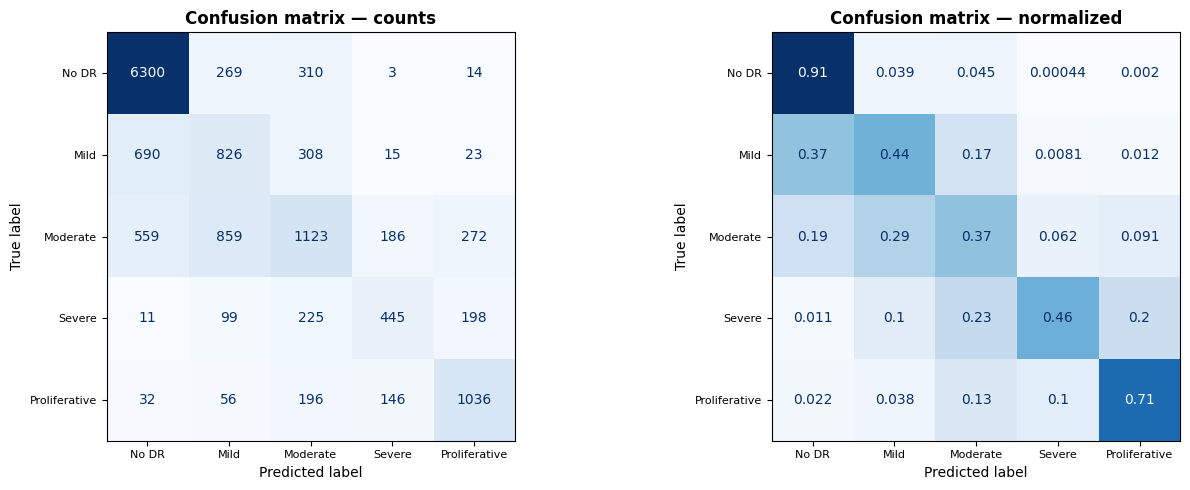

Saved → confusion_matrix_v2.png


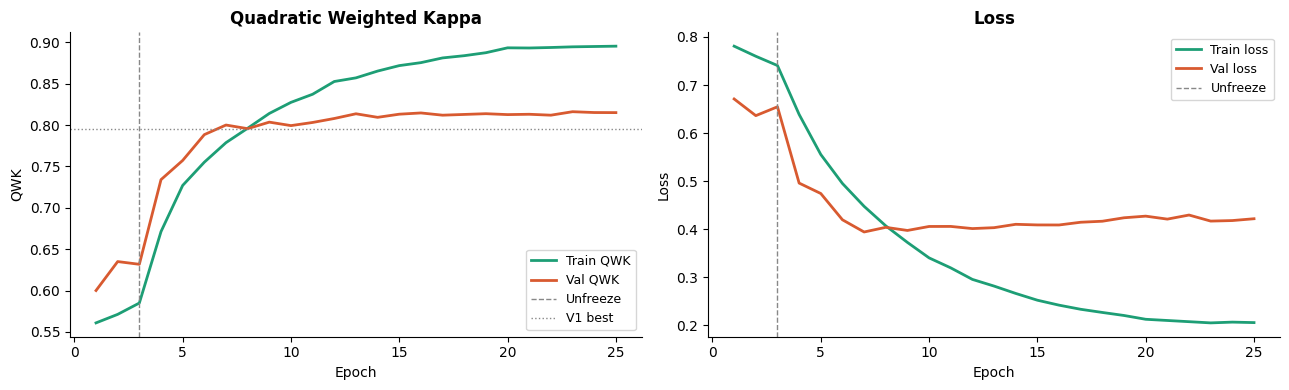

Saved → training_curves_v2.png

Generating Grad-CAM visualizations...


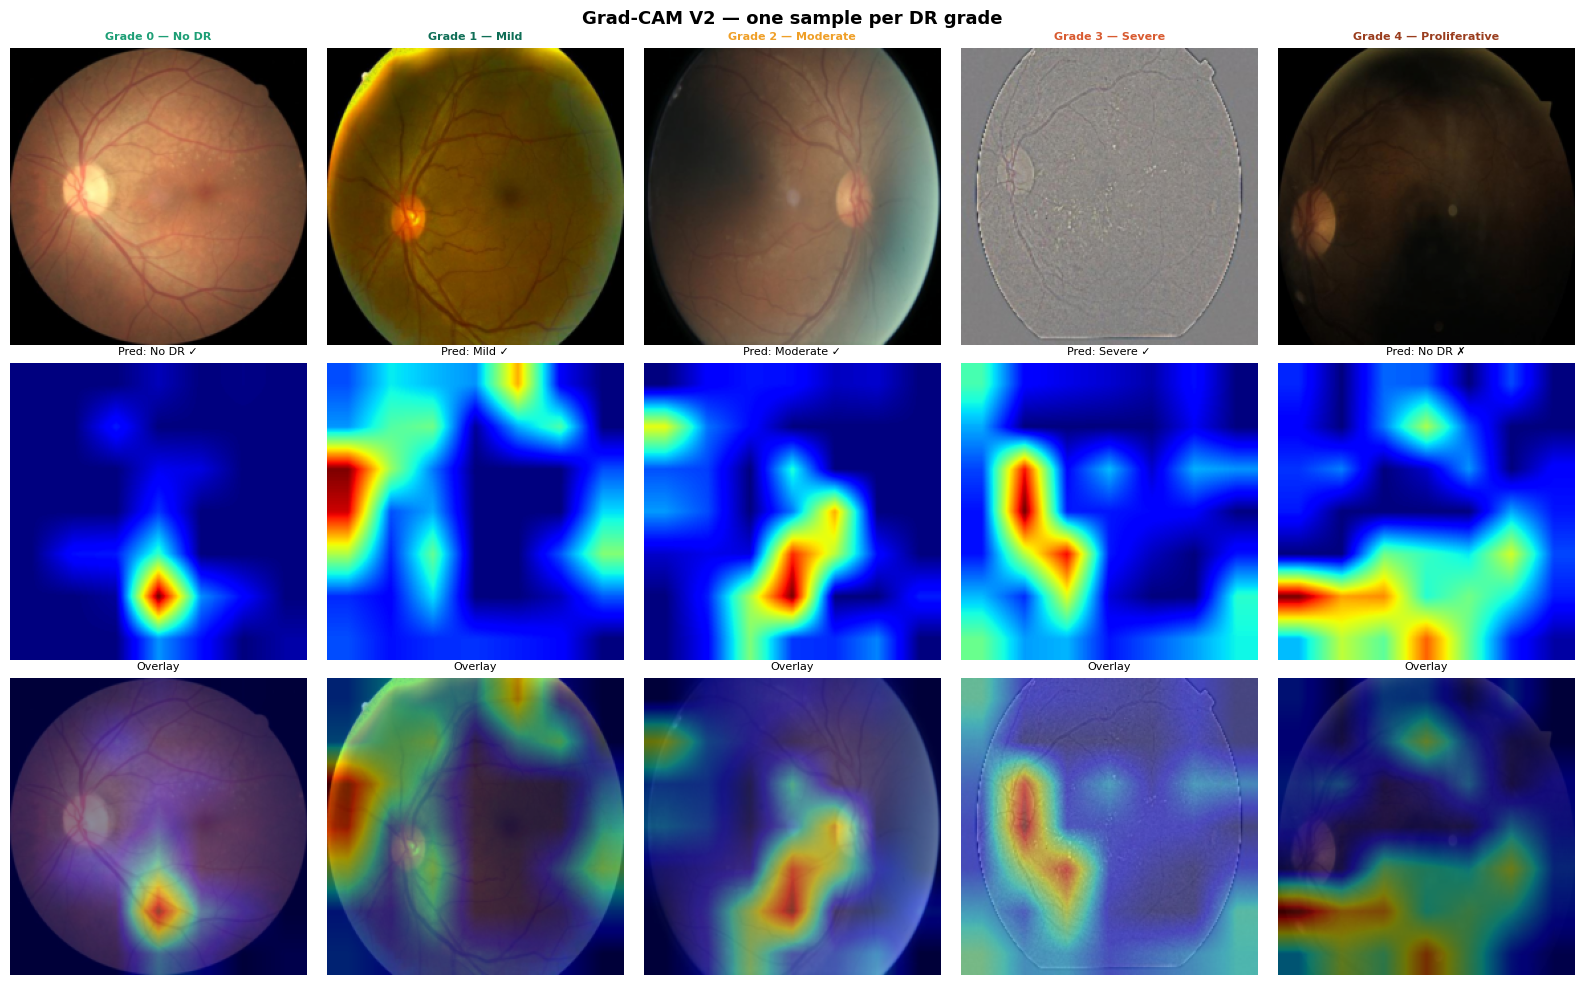

Saved → gradcam_v2.png

  V1 vs V2 COMPARISON
  Metric                     V1       V2    Delta
  ──────────────────────────────────────────────
  Val QWK                0.7942   0.8161  +0.0219
  Test QWK               0.7957   0.8084  +0.0127
  Test AUC-ROC           0.8412   0.8399  -0.0013
  Test Accuracy           67.1%    68.5%    +1.4%

✓ Evaluation complete.
  All outputs saved to /kaggle/working/


In [8]:
# ── Cell 5 · Evaluation & Grad-CAM · V2 ──────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay
)
import torch
import torch.nn.functional as F
from PIL import Image

# ── 1. Load best checkpoint ───────────────────────────────────────────────────
print("Loading best checkpoint...")
ckpt = torch.load(
    "/kaggle/working/checkpoint_best.pt",
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"  Loaded epoch {ckpt['epoch']+1}  |  best val QWK = {ckpt['best_qwk']:.4f}")

# ── 2. Test set inference ─────────────────────────────────────────────────────
print("\nRunning test set inference...")
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs .extend(probs)
        all_preds .extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs, dtype=np.float64)
all_probs  = all_probs / all_probs.sum(axis=1, keepdims=True)

# ── 3. Core metrics ───────────────────────────────────────────────────────────
qwk = quadratic_weighted_kappa(all_labels, all_preds)
acc = (all_preds == all_labels).mean()
auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")

print("\n" + "=" * 50)
print(f"  Test QWK      : {qwk:.4f}  (V1: 0.7957)")
print(f"  Test Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Test AUC-ROC  : {auc:.4f}  (V1: 0.8412)")
print("=" * 50)

# ── 4. Per-class report ───────────────────────────────────────────────────────
print("\nPer-class report:")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3
))

# ── 5. Confusion matrix ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

cm_counts = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm_counts, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix — counts", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", labelsize=8)
axes[0].tick_params(axis="y", labelsize=8)

cm_norm = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES)
disp2.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion matrix — normalized", fontsize=12, fontweight="bold")
axes[1].tick_params(axis="x", labelsize=8)
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrix_v2.png")

# ── 6. Training curves ────────────────────────────────────────────────────────
import json
with open("/kaggle/working/history.json") as f:
    history = json.load(f)

epochs = range(1, len(history["train_qwk"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor("white")

ax = axes[0]
ax.plot(epochs, history["train_qwk"], color="#1D9E75", label="Train QWK", linewidth=2)
ax.plot(epochs, history["val_qwk"],   color="#D85A30", label="Val QWK",   linewidth=2)
ax.axvline(x=UNFREEZE_EPOCH, color="#888", linestyle="--", linewidth=1, label="Unfreeze")
ax.axhline(y=0.7957, color="#888", linestyle=":", linewidth=1, label="V1 best")
ax.set_title("Quadratic Weighted Kappa", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("QWK")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

ax2 = axes[1]
ax2.plot(epochs, history["train_loss"], color="#1D9E75", label="Train loss", linewidth=2)
ax2.plot(epochs, history["val_loss"],   color="#D85A30", label="Val loss",   linewidth=2)
ax2.axvline(x=UNFREEZE_EPOCH, color="#888", linestyle="--", linewidth=1, label="Unfreeze")
ax2.set_title("Loss", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_curves_v2.png")

# ── 7. Grad-CAM ───────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        logits     = self.model(img_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                                mode="bilinear", align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

target_layer = model.backbone.features[-1]
gradcam      = GradCAM(model, target_layer)

# ── 8. Grad-CAM visualization ─────────────────────────────────────────────────
print("\nGenerating Grad-CAM visualizations...")
PALETTE = ["#1D9E75", "#0F6E56", "#EF9F27", "#D85A30", "#993C1D"]

inv_mean = [-m/s for m, s in zip([0.485,0.456,0.406], [0.229,0.224,0.225])]
inv_std  = [1/s for s in [0.229, 0.224, 0.225]]
inv_norm = T.Normalize(mean=inv_mean, std=inv_std)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle("Grad-CAM V2 — one sample per DR grade", fontsize=13, fontweight="bold")
fig.patch.set_facecolor("white")

for grade in range(NUM_CLASSES):
    idx       = next(i for i, s in enumerate(test_dataset.samples) if s[1] == grade)
    img_t, _  = test_dataset[idx]
    cam, pred = gradcam.generate(img_t)

    orig    = inv_norm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()
    heatmap = mpl_cm.jet(cam)[..., :3]
    overlay = (0.55 * orig + 0.45 * heatmap).clip(0, 1)

    correct = "✓" if pred == grade else "✗"

    axes[0][grade].imshow(orig)
    axes[0][grade].set_title(f"Grade {grade} — {CLASS_NAMES[grade]}",
                              fontsize=8, color=PALETTE[grade], fontweight="bold")
    axes[0][grade].axis("off")

    axes[1][grade].imshow(cam, cmap="jet")
    axes[1][grade].set_title(f"Pred: {CLASS_NAMES[pred]} {correct}", fontsize=8)
    axes[1][grade].axis("off")

    axes[2][grade].imshow(overlay)
    axes[2][grade].set_title("Overlay", fontsize=8)
    axes[2][grade].axis("off")

axes[0][0].set_ylabel("Original",  fontsize=9, fontweight="bold")
axes[1][0].set_ylabel("Grad-CAM",  fontsize=9, fontweight="bold")
axes[2][0].set_ylabel("Overlay",   fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → gradcam_v2.png")

# ── 9. V1 vs V2 comparison ───────────────────────────────────────────────────
print("\n" + "=" * 50)
print("  V1 vs V2 COMPARISON")
print("=" * 50)
print(f"  {'Metric':<20} {'V1':>8} {'V2':>8} {'Delta':>8}")
print("  " + "─" * 46)
print(f"  {'Val QWK':<20} {'0.7942':>8} {ckpt['best_qwk']:>8.4f} {ckpt['best_qwk']-0.7942:>+8.4f}")
print(f"  {'Test QWK':<20} {'0.7957':>8} {qwk:>8.4f} {qwk-0.7957:>+8.4f}")
print(f"  {'Test AUC-ROC':<20} {'0.8412':>8} {auc:>8.4f} {auc-0.8412:>+8.4f}")
print(f"  {'Test Accuracy':<20} {'67.1%':>8} {acc*100:>7.1f}% {(acc-0.671)*100:>+7.1f}%")
print("=" * 50)

print("\n✓ Evaluation complete.")
print("  All outputs saved to /kaggle/working/")

In [20]:
import torch

# ── Export ONNX ───────────────────────────────────────────────────────────────
model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

torch.onnx.export(
    model,
    dummy_input,
    "/kaggle/working/dr_model_v2.onnx",
    export_params   = True,
    opset_version   = 17,
    do_constant_folding = True,
    input_names     = ["image"],
    output_names    = ["logits"],
    dynamic_axes    = {
        "image"  : {0: "batch_size"},
        "logits" : {0: "batch_size"},
    }
)

print("✓ ONNX exported")

# vérifie la taille
import os
size = os.path.getsize("/kaggle/working/dr_model_v2.onnx") / 1024 / 1024
print(f"  Size : {size:.1f} MB")

W0523 22:06:54.672000 57 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0523 22:06:56.134000 57 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0523 22:06:56.135000 57 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int

[torch.onnx] Obtain model graph for `DRClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DRClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

✓ ONNX exported
  Size : 1.3 MB

  ⏱  Auto-save → /kaggle/working/  (epoch=23 QWK=0.8161)
